In [1]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
tips = sns.load_dataset("tips")

# Select numeric columns
numeric_cols = tips.select_dtypes(include=['float64','int64'])

# Step 1: Standardize the data (important for PCA)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)
# Step 2: Apply PCA
pca = PCA(n_components=2)   # project data into 2 dimensions
pca_result = pca.fit_transform(scaled_data)
# Step 3: Create a DataFrame with PCA results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1','PC2'])
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("\nPCA Result (first 5 rows):")
print(pca_df.head())


Explained variance ratio: [0.72627656 0.1730423 ]

PCA Result (first 5 rows):
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


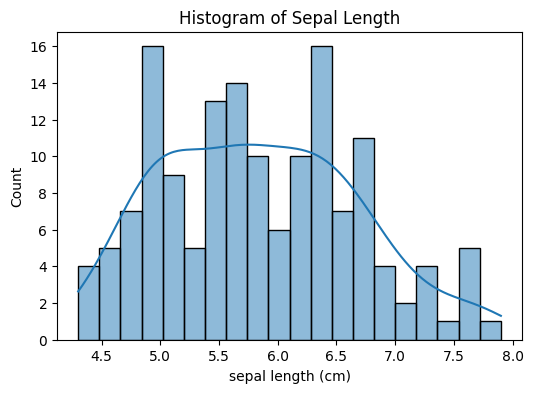

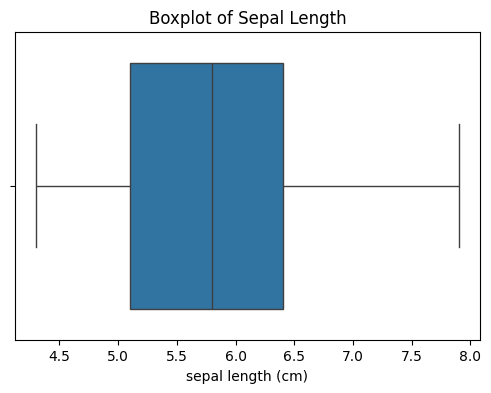

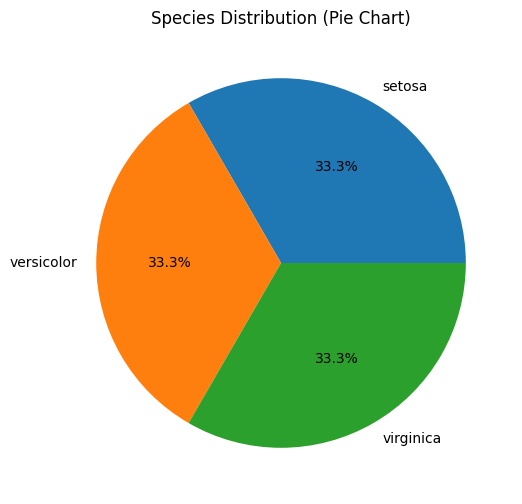

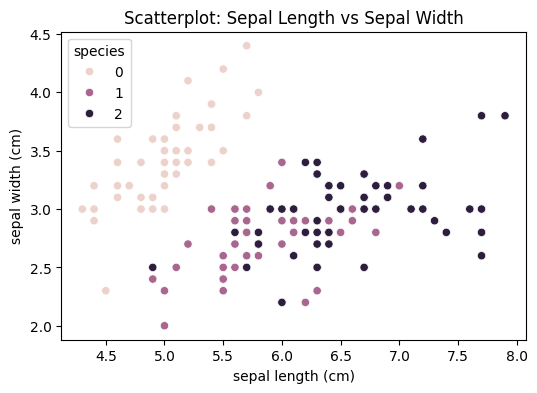

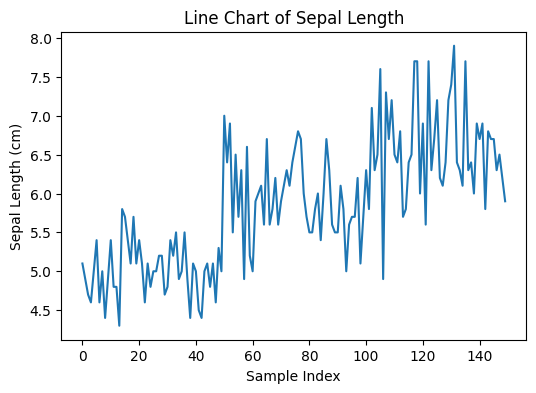

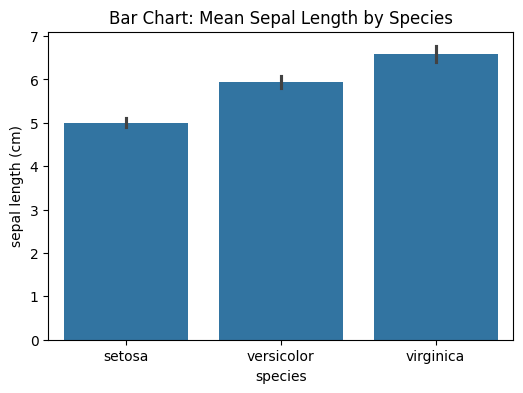

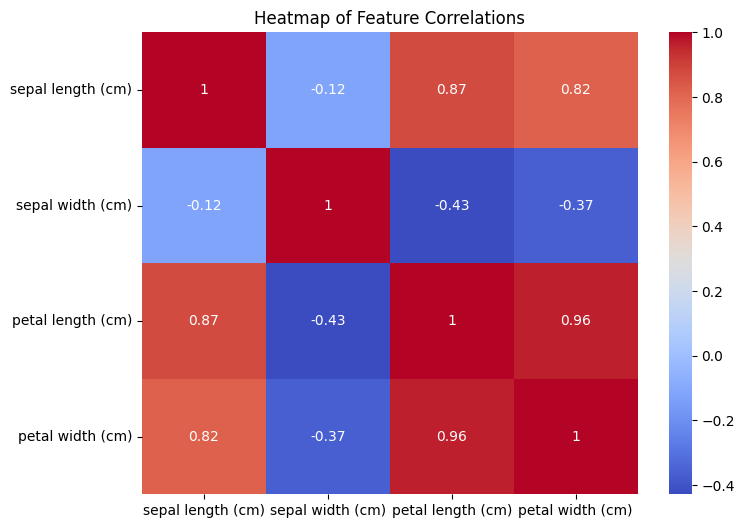

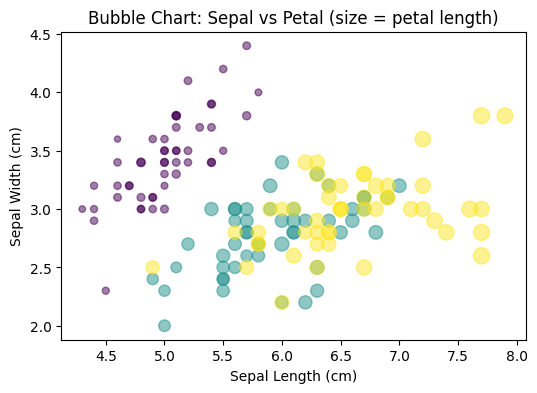

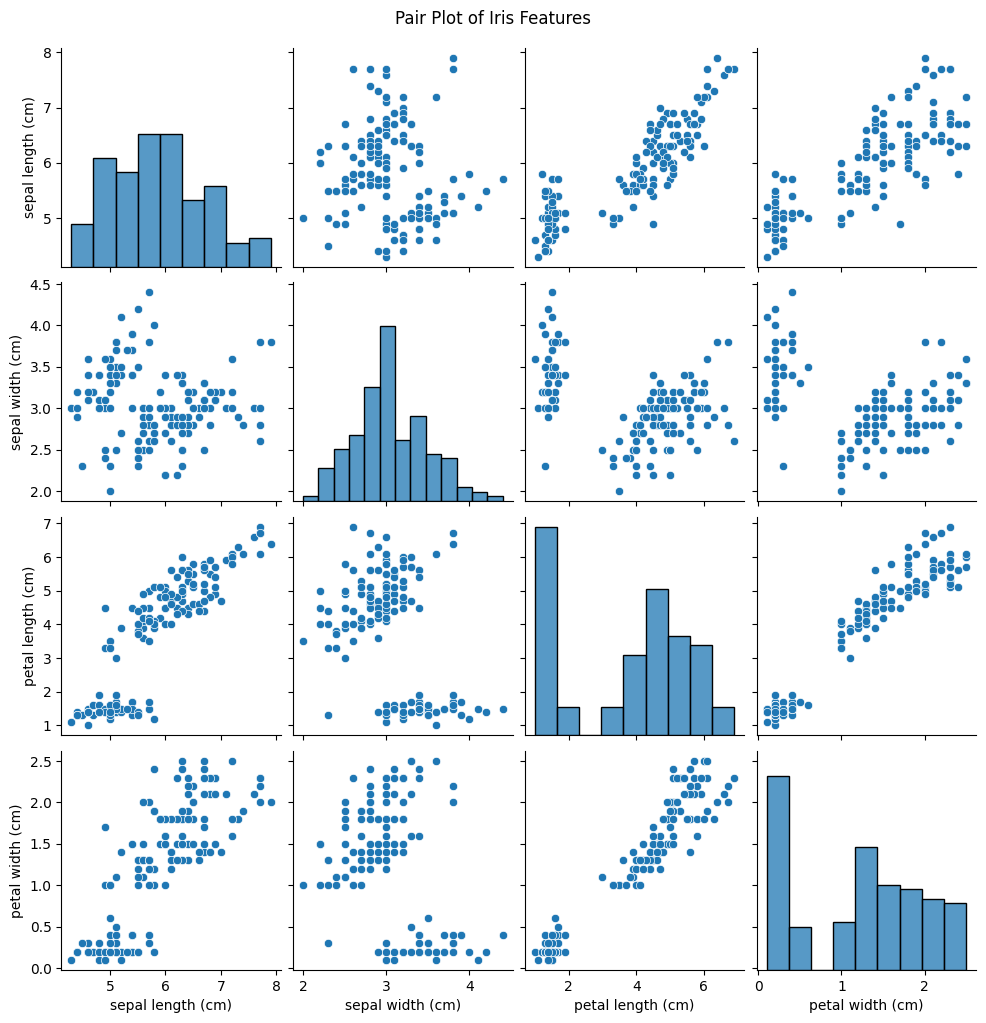

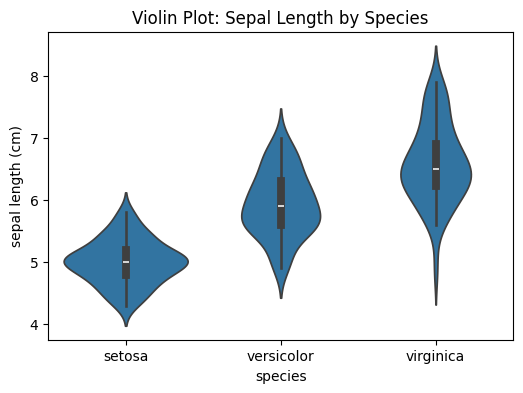

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target
# 1. Univariate Visualizations
# Histogram
plt.figure(figsize=(6,4))
sns.histplot(df['sepal length (cm)'], bins=20, kde=True)
plt.title("Histogram of Sepal Length")
plt.show()

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x=df['sepal length (cm)'])
plt.title("Boxplot of Sepal Length")
plt.show()

# Pie Chart (species distribution)
species_counts = df['species'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(species_counts, labels=iris.target_names, autopct='%1.1f%%')
plt.title("Species Distribution (Pie Chart)")
plt.show()

# 2. Bivariate Visualizations

# Scatterplot
plt.figure(figsize=(6,4))
sns.scatterplot(x=df['sepal length (cm)'], y=df['sepal width (cm)'], hue=df['species'])
plt.title("Scatterplot: Sepal Length vs Sepal Width")
plt.show()
# Line Chart (trend of sepal length across samples)
plt.figure(figsize=(6,4))
plt.plot(df['sepal length (cm)'])
plt.title("Line Chart of Sepal Length")
plt.xlabel("Sample Index")
plt.ylabel("Sepal Length (cm)")
plt.show()
# Bar Chart (mean sepal length per species)
plt.figure(figsize=(6,4))
sns.barplot(x=df['species'], y=df['sepal length (cm)'])
plt.title("Bar Chart: Mean Sepal Length by Species")
plt.xticks([0,1,2], iris.target_names)
plt.show()
# 3. Multivariate Visualizations
# Heatmap (correlation matrix)
plt.figure(figsize=(8,6))
sns.heatmap(df.iloc[:,:4].corr(), annot=True, cmap="coolwarm")
plt.title("Heatmap of Feature Correlations")
plt.show()
# Bubble Chart (scatterplot with size = petal length)
plt.figure(figsize=(6,4))
plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'],
            s=df['petal length (cm)']*20, alpha=0.5, c=df['species'])
plt.title("Bubble Chart: Sepal vs Petal (size = petal length)")
plt.xlabel("Sepal Length (cm)")
plt.ylabel("Sepal Width (cm)")
plt.show()
# Pair Plot (relationships among all features)
sns.pairplot(df.iloc[:,:4])
plt.suptitle("Pair Plot of Iris Features", y=1.02)
plt.show()
# 4. Advanced Techniques
# Violin Plot
plt.figure(figsize=(6,4))
sns.violinplot(x=df['species'], y=df['sepal length (cm)'])
plt.title("Violin Plot: Sepal Length by Species")
plt.xticks([0,1,2], iris.target_names)
plt.show()
